## финальная resnet-50

In [ ]:
import numpy
from collections import OrderedDict

In [ ]:
mixup = v2.MixUp(alpha=0.2, num_classes=9)

In [ ]:
model = models.resnet50(weights=None)

model.fc = nn.Sequential(
    nn.Linear(2048, 1024),
    nn.SiLU(),
    nn.Linear(1024, 512),
    nn.LayerNorm(512),
    nn.SiLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 9)
)

checkpoint = torch.load('/content/drive/MyDrive/практика_модель/дообуч_миксап/best_checkpoint_model_mixup_model_0.3.pth', weights_only=False)

state_dict = {k: v for k, v in checkpoint['model_state_dict'].items() if 'fc' not in k}
model.load_state_dict(state_dict, strict=False)

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

optimizer = torch.optim.AdamW([
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(), 'lr': 0.0001}
], weight_decay=0.001)


exp_lr_scheduler = lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30,
    eta_min=1e-7
)

criterion = nn.CrossEntropyLoss()

In [ ]:
model, metrics = train_model(model, criterion, optimizer, exp_lr_scheduler, dataloaders, dataset_sizes, '/content/drive/MyDrive/практика_модель', '0.2_разморозка_обучение новой головы_с_дропаут', 30)

Epoch 1/30
----------
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


train Loss: 1.4217 | Acc: 0.3315 | Weighted Acc: 0.2379 | F1-macro: 0.3203 | Top-1 Acc: 0.3315 | Top-3 Acc: 0.6047
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


val Loss: 0.9346 | Acc: 0.6743 | Weighted Acc: 0.6279 | F1-macro: 0.6620 | Top-1 Acc: 0.6743 | Top-3 Acc: 0.9251
Epoch Time: 197.3967s

Epoch 2/30
----------
Iterating through data...


...

val Loss: 0.5899 | Acc: 0.8135 | Weighted Acc: 0.7882 | F1-macro: 0.8133 | Top-1 Acc: 0.8135 | Top-3 Acc: 0.9617
Epoch Time: 192.2408s

Epoch 30/30
----------
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


train Loss: 0.7081 | Acc: 0.5227 | Weighted Acc: 0.4609 | F1-macro: 0.5211 | Top-1 Acc: 0.5227 | Top-3 Acc: 0.7171
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


val Loss: 0.5942 | Acc: 0.8103 | Weighted Acc: 0.7827 | F1-macro: 0.8095 | Top-1 Acc: 0.8103 | Top-3 Acc: 0.9585
Epoch Time: 192.3561s

Training complete in 96m 48s
Best val Weighted Acc: 0.788167 | Best F1-score: 0.8133 | Best Top-1 Acc: 0.8135 | Best Top-3 Acc: 0.9650


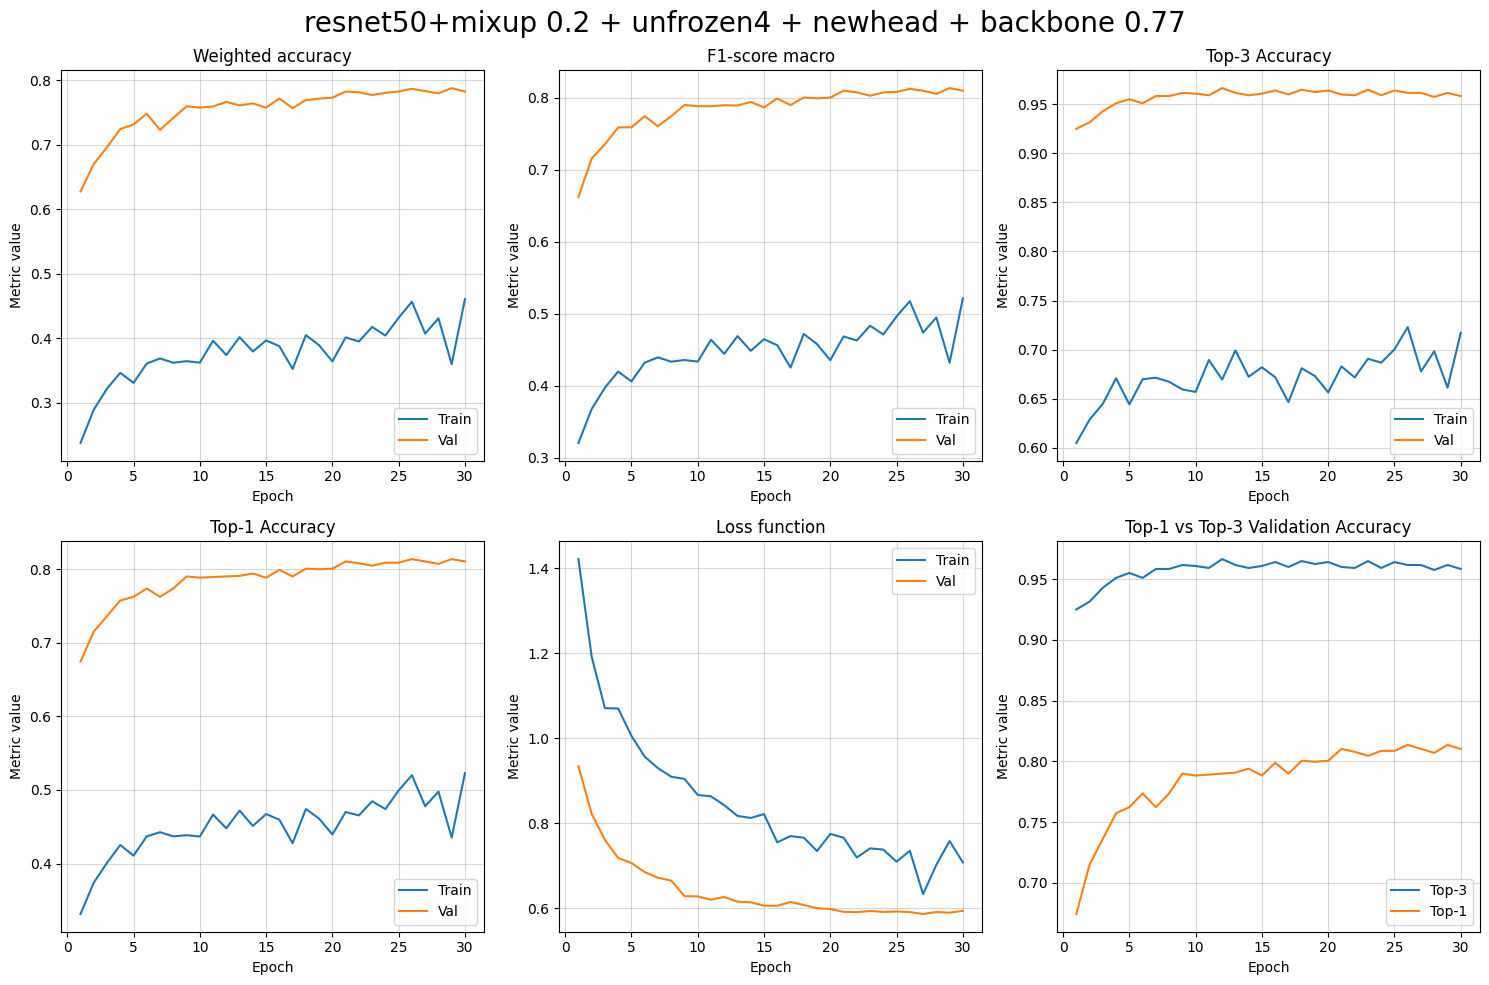

In [ ]:
visualize_metrics(metrics, 'resnet50+mixup 0.2 + unfrozen4 + newhead + backbone 0.77', 30)

In [ ]:
train_set, val_set, test_set = dataloaders['train'], dataloaders['val'], dataloaders['test']

In [ ]:
model = torch.load('/content/drive/MyDrive/практика_модель/дообуч_миксап/best_model_0.1_разморозка_дообучение.pt')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


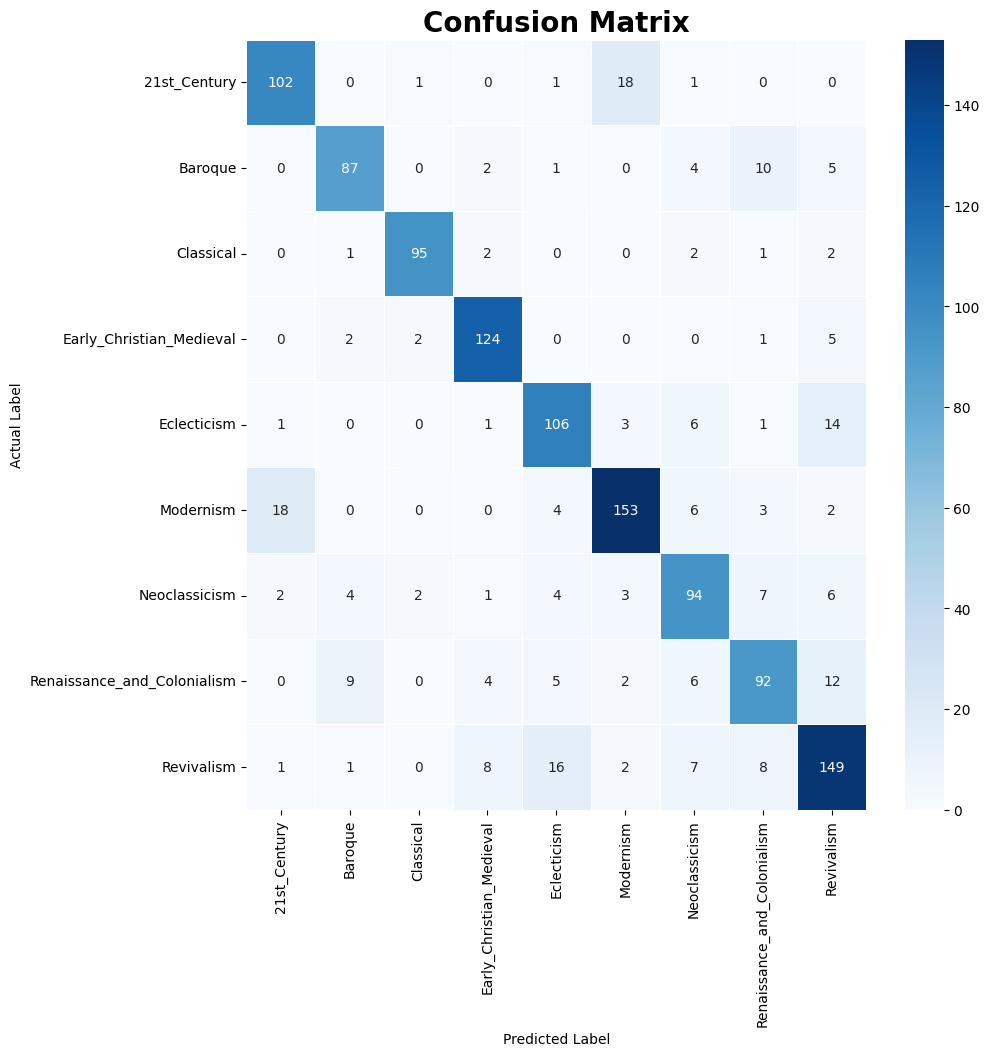

In [ ]:
visualize_cm(model, class_names, test_set)